In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

In [ ]:
df = pd.read_csv("3) Sentiment dataset.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [ ]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,44
Joy,42
Excitement,32
Happy,14
Neutral,14
...,...
Vibrancy,1
Culinary Adventure,1
Mesmerizing,1


In [ ]:
df = df[["Text", "Sentiment"]]

df.head()

,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


In [ ]:
df.isnull().sum()

,0
Text,0
Sentiment,0


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Text"] = df["Text"].apply(clean_text)

df.head()

,Text,Sentiment,Clean_Text
0,Enjoying a beautiful day at the park! ...,Positive,enjoying a beautiful day at the park
1,Traffic was terrible this morning. ...,Negative,traffic was terrible this morning
2,Just finished an amazing workout! 💪 ...,Positive,just finished an amazing workout
3,Excited about the upcoming weekend getaway! ...,Positive,excited about the upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,Neutral,trying out a new recipe for dinner tonight


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Text"] = df["Text"].apply(clean_text)

df.head()

,Text,Sentiment,Clean_Text
0,Enjoying a beautiful day at the park! ...,Positive,enjoying a beautiful day at the park
1,Traffic was terrible this morning. ...,Negative,traffic was terrible this morning
2,Just finished an amazing workout! 💪 ...,Positive,just finished an amazing workout
3,Excited about the upcoming weekend getaway! ...,Positive,excited about the upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,Neutral,trying out a new recipe for dinner tonight


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Attempting to download punkt_tab as suggested by the error
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["Tokens"] = df["Clean_Text"].apply(nltk.word_tokenize)

df["Filtered_Text"] = df["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Text,Sentiment,Clean_Text,Tokens,Filtered_Text
0,Enjoying a beautiful day at the park! ...,Positive,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]"
1,Traffic was terrible this morning. ...,Negative,traffic was terrible this morning,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]"
2,Just finished an amazing workout! 💪 ...,Positive,just finished an amazing workout,"[just, finished, an, amazing, workout]","[finished, amazing, workout]"
3,Excited about the upcoming weekend getaway! ...,Positive,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]"
4,Trying out a new recipe for dinner tonight. ...,Neutral,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]"


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["Filtered_Text"] = df["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

df.head()

,Text,Sentiment,Clean_Text,Tokens,Filtered_Text
0,Enjoying a beautiful day at the park! ...,Positive,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]"
1,Traffic was terrible this morning. ...,Negative,traffic was terrible this morning,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]"
2,Just finished an amazing workout! 💪 ...,Positive,just finished an amazing workout,"[just, finished, an, amazing, workout]","[finished, amazing, workout]"
3,Excited about the upcoming weekend getaway! ...,Positive,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]"
4,Trying out a new recipe for dinner tonight. ...,Neutral,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]"


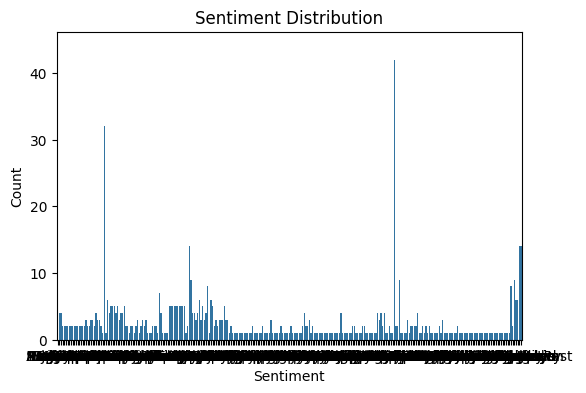

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [ ]:
pip install wordcloud

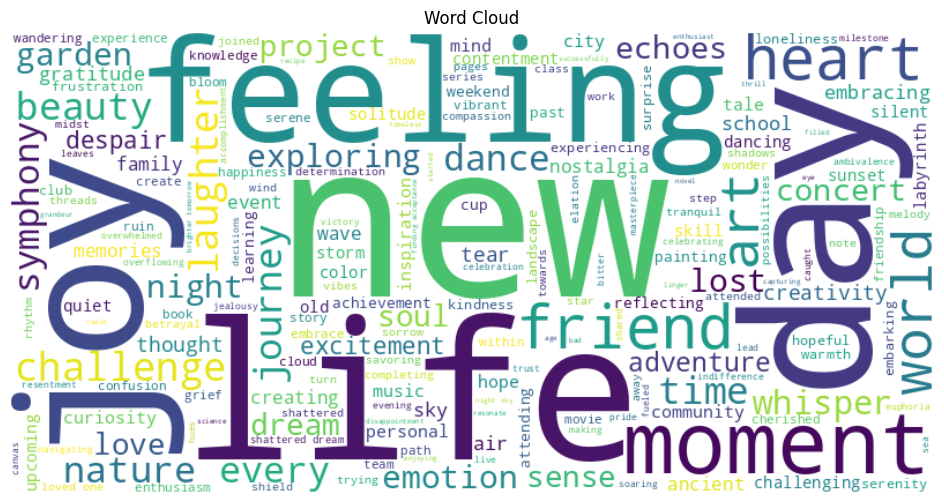

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Sentiment"] = encoder.fit_transform(df["Sentiment"])

df.head()

,Text,Sentiment,Clean_Text,Tokens,Filtered_Text
0,Enjoying a beautiful day at the park! ...,214,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]"
1,Traffic was terrible this morning. ...,195,traffic was terrible this morning,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]"
2,Just finished an amazing workout! 💪 ...,214,just finished an amazing workout,"[just, finished, an, amazing, workout]","[finished, amazing, workout]"
3,Excited about the upcoming weekend getaway! ...,214,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]"
4,Trying out a new recipe for dinner tonight. ...,197,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]"


# Conclusion

A sentiment analysis workflow was performed on the social media dataset.

- The dataset was loaded and inspected.
- Missing values were checked.
- Text was cleaned by converting to lowercase and removing URLs, punctuation, and extra spaces.
- Tokenization and stopword removal were performed.
- A sentiment distribution chart and word cloud were created to visualize the text data.

The processed dataset is ready for further NLP and machine learning tasks.